# Multi Agent

- [LangChain:Multi-agent](https://docs.langchain.com/oss/python/langchain/multi-agent)
  - [GitHub](https://github.com/langchain-ai/langgraph/blob/23961cff61a42b52525f3b20b4094d8d2fba1744/docs/docs/agents/multi-agent.md)
- [LangGraph:langgraph-supervisor](https://reference.langchain.com/python/langgraph-supervisor)
  - [GitHub](https://github.com/langchain-ai/langgraph/blob/23961cff61a42b52525f3b20b4094d8d2fba1744/docs/docs/concepts/multi_agent.md)

In [105]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

## [Yahoo finance News](https://docs.langchain.com/oss/python/integrations/tools/yahoo_finance_news)

In [106]:
%pip install -q yfinance

Note: you may need to restart the kernel to use updated packages.


In [107]:
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain.agents import create_agent

from langchain_core.messages import HumanMessage
from langgraph.graph import MessagesState
from langgraph.types import Command

from typing import Literal

market_research_agent = create_agent(
    llm,
    tools=[YahooFinanceNewsTool()],
    system_prompt='You are a market researcher. Provide fact only not opinions'
)

def market_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = market_research_agent.invoke(state)

    message = HumanMessage(
        content=result['messages'][-1].content,
        name = 'market_research'
    )

    return Command(
        update={'messages': [message]},
        goto='supervisor'
    )

In [108]:
from langchain.tools import tool

import yfinance as yf

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info

In [109]:
get_stock_price.invoke({'ticker': 'AAPL'})

[*********************100%***********************]  1 of 1 completed
Error in LangChainTracer.on_tool_end callback: TypeError('keys must be str, int, float, bool or None, not tuple')


{('Close', 'AAPL'): {Timestamp('2026-04-20 00:00:00'): 272.79864501953125,
  Timestamp('2026-04-21 00:00:00'): 265.9250183105469,
  Timestamp('2026-04-22 00:00:00'): 272.9185791015625,
  Timestamp('2026-04-23 00:00:00'): 273.1783142089844,
  Timestamp('2026-04-24 00:00:00'): 270.81048583984375,
  Timestamp('2026-04-27 00:00:00'): 267.3636474609375,
  Timestamp('2026-04-28 00:00:00'): 270.4608154296875,
  Timestamp('2026-04-29 00:00:00'): 269.92132568359375,
  Timestamp('2026-04-30 00:00:00'): 271.1002502441406,
  Timestamp('2026-05-01 00:00:00'): 279.88214111328125,
  Timestamp('2026-05-04 00:00:00'): 276.5751647949219,
  Timestamp('2026-05-05 00:00:00'): 283.9184265136719,
  Timestamp('2026-05-06 00:00:00'): 287.245361328125,
  Timestamp('2026-05-07 00:00:00'): 287.1754150390625,
  Timestamp('2026-05-08 00:00:00'): 293.0500183105469,
  Timestamp('2026-05-11 00:00:00'): 292.67999267578125,
  Timestamp('2026-05-12 00:00:00'): 294.79998779296875,
  Timestamp('2026-05-13 00:00:00'): 298.8

In [110]:
stock_research_agent = create_agent(
    llm,
    tools=[get_stock_price],
    system_prompt='You are a stock researcher. Provide facts only not opinions'
)

In [111]:
def stock_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = stock_research_agent.invoke(state)

    message = HumanMessage(
        content=result['messages'][-1].content,
        name='stock_research'
    )

    return Command(
        update={'messages': [message]},
        goto='supervisor'
    )

In [112]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)

    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()

    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_agent = create_agent(
    llm,
    tools=[company_research_tool],
    system_prompt='You are a company researcher. Provide facts only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal['supervisor']]:
    result = company_research_agent.invoke(state)

    message = HumanMessage(
        content=result['messages'][-1].content,
        name = 'company_research'
    )

    return Command(
        update={'messages': [message]},
        goto='supervisor'
    )

In [113]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template('''You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.
Please provide your final answer in Korean, and include the reason.

Information:
{messages}''')

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    result = analyst_chain.invoke({'messages': state['messages'][1:]})
    return {'messages': [result]}

In [114]:
from typing import Literal
from langgraph.types import TypedDict, Command
from langgraph.graph import MessagesState, END

members = ['market_research', 'stock_research', 'company_research']
options = members + ['FINISH']

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""
    next: Literal[*options]

def supervisor_node(state: MessagesState) -> Command[Literal[*members, 'analyst']]:
  messages = [
    {'role': 'system', 'content': system_prompt}
  ] + state['messages']

  response = llm.with_structured_output(Router).invoke(messages)
  goto = response['next']

  if (goto == 'FINISH'):
     goto = 'analyst'
  
  return Command(goto=goto)

In [115]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(MessagesState)

graph_builder.add_node('supervisor', supervisor_node)
graph_builder.add_node('market_research', market_research_node)
graph_builder.add_node('stock_research', stock_research_node)
graph_builder.add_node('company_research', company_research_node)
graph_builder.add_node('analyst', analyst_node)

In [116]:
graph_builder.add_edge(START, 'supervisor')
graph_builder.add_edge('analyst', END)

In [117]:
graph = graph_builder.compile()

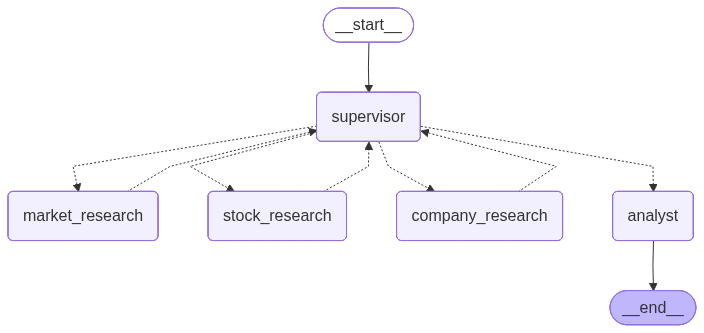

In [118]:
graph

In [119]:
for chunk in graph.stream(
    {'messages': ['user', '삼성전자 주식을 사야할까?']},
    stream_mode='values'
):
  chunk['messages'][-1].pretty_print()

================================ Human Message =================================

삼성전자 주식을 사야할까?
================================ Human Message =================================
Name: market_research

현재 "005930.KS" (삼성전자)에 대한 최신 금융 뉴스를 찾을 수 없습니다. 추가적인 정보가 필요하시다면, 직접 금융 포털 사이트나 뉴스 매체를 통해 최신 정보를 확인하는 것이 좋습니다. 또한, 주식 투자 결정은 다양한 요인들을 고려하여 진행해야 하므로, 전문가의 조언을 참고하는 것도 도움이 될 수 있습니다.


[*********************100%***********************]  1 of 1 completed


================================ Human Message =================================
Name: stock_research

최근 한 달 동안 "005930.KS" (삼성전자)의 주가 변동은 다음과 같습니다:

- 시작가 (Open): 2026-04-20에 214,500원에서 시작하여, 2026-05-19에 274,000원으로 마감되었습니다.
- 종가 (Close): 2026-04-20에 214,500원에서 시작하여, 2026-05-19에 275,500원으로 마감되었습니다.
- 최고가 (High): 한 달 동안 최고가는 2026-05-14에 299,500원으로 기록되었습니다.
- 최저가 (Low): 한 달 동안 최저가는 2026-04-20에 213,000원으로 기록되었습니다.
- 거래량 (Volume): 최고 거래량은 2026-05-06에 53,097,996주로 기록되었습니다.

이 주가 정보는 주식의 과거 성과를 보여주며, 주식 매수 여부를 결정하기 위해서는 추가적인 정보와 분석이 필요합니다.


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: 005930.KS"}}}


================================ Human Message =================================
Name: company_research

삼성전자(005930.KS)의 최근 연말 재무 정보는 다음과 같습니다:

- 2025년:
  - 총 수익: 333조 6,059억 원
  - 총 비용: 290조 0,049억 원
  - 순이익: 44조 2,610억 원
  - 기본주당순이익(EPS): 6,605원
  - 연구개발비: 37조 7,403억 원

- 2024년:
  - 총 수익: 300조 8,709억 원
  - 총 비용: 268조 1,449억 원
  - 순이익: 33조 6,213억 원
  - 기본주당순이익(EPS): 4,950원
  - 연구개발비: 34조 9,814억 원

- 2023년:
  - 총 수익: 258조 9,355억 원
  - 총 비용: 252조 3,685억 원
  - 순이익: 14조 4,734억 원
  - 기본주당순이익(EPS): 2,131원
  - 연구개발비: 28조 3,397억 원

- 2022년:
  - 총 수익: 302조 2,314억 원
  - 총 비용: 258조 8,547억 원
  - 순이익: 54조 7,302억 원
  - 기본주당순이익(EPS): 8,057원
  - 연구개발비: 24조 9,192억 원

이 정보는 삼성전자의 과거 재무 성과를 나타내며, 투자 결정을 고려할 때 참고할 수 있는 데이터입니다. 주식 투자 결정을 내리기 위해서는 이러한 재무 성과 외에도 다양한 요인을 고려하는 것이 중요합니다.
================================== Ai Message ==================================

보유

삼성전자의 최근 한 달 주가 및 연말 재무 정보를 고려했을 때 삼성전자 주식은 "보유"를 추천합니다. 최근 한 달간 주가가 상승 추세를 보였으며, 특히 종가와 최고가 모두 상승하였습니다. 또한, 최근 연말 재무 정보를 보면 수익성과 연구개발에 꾸준